In [78]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, f1_score
import time

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models_eval import eval_pipeline, eval_combination_matrix

from rital_nlp_project.presidents.utils import smooth_predictions

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
texts_pres, classes_pres = load_clean_data("../Dataset/presidents_clean.parquet")

In [3]:
max_features = 5000
min_df = 5
max_df = 0.5

vectorizer_list = [
    CountVectorizer(analyzer="char", ngram_range=(1, 1), max_features=max_features),
    CountVectorizer(analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),
    CountVectorizer(analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    CountVectorizer(analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),

    TfidfVectorizer(analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),
]

classifier_list = [
    LogisticRegression(max_iter=100),
    MultinomialNB(), 
    LinearSVC(),
    #SVC(kernel="rbf")
]

### Separated phrases

In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(texts_pres, classes_pres, random_state=42)

In [3]:
#results = eval_combination_matrix(X_train, y_train, X_test, y_test, vectorizer_list, classifier_list)
#results.to_csv("out/baseline_eval_matrix_pres.csv", index=False)
results = pd.read_csv("out/baseline_eval_matrix_pres.csv")

Text(0.5, 1.0, 'F1-score')

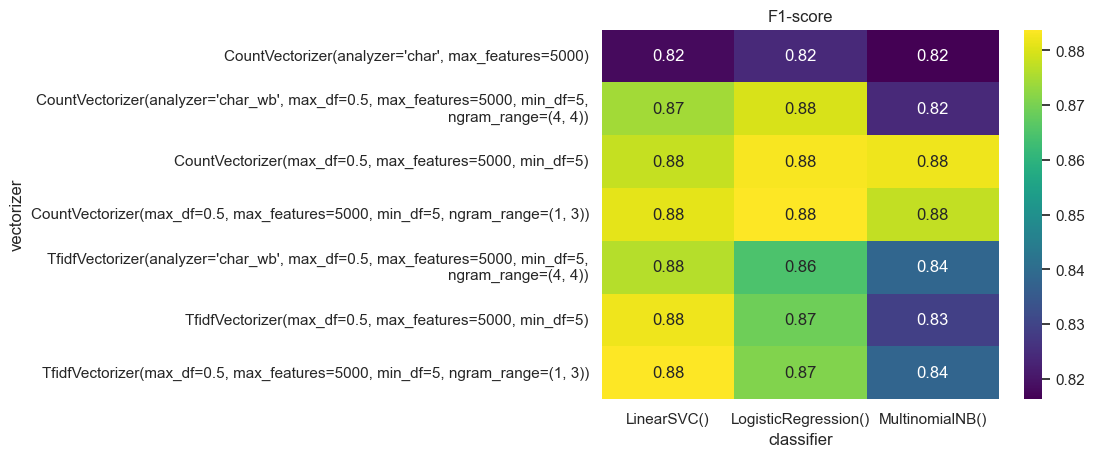

In [7]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="f1"), annot=True, cmap="viridis")
plt.title("F1-score")

Text(0.5, 1.0, 'Train time')

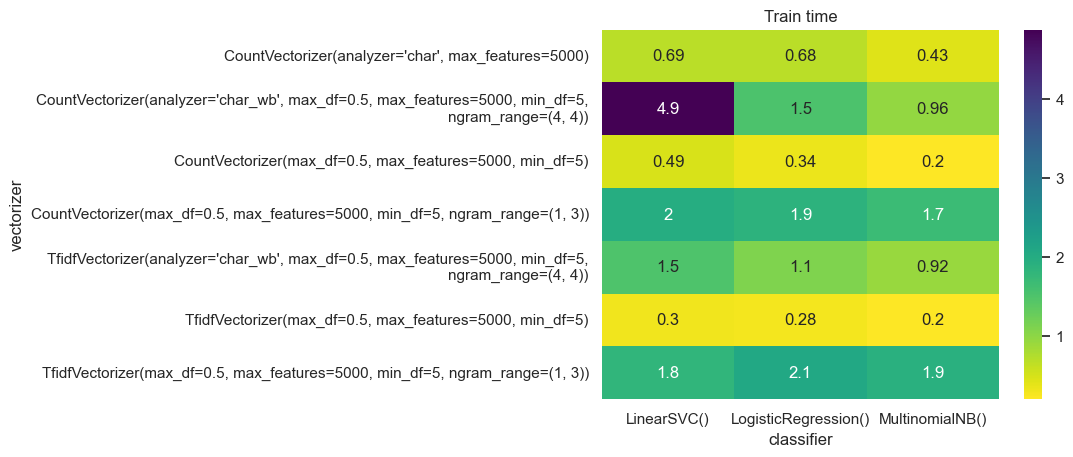

In [6]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="train_time"), annot=True, cmap="viridis_r")
plt.title("Train time")

### Try smoothing

In [105]:
# Pick one of the best performing model
pipeline = Pipeline([
    ("vectorizer", CountVectorizer(analyzer="word", ngram_range=(1, 1), min_df=min_df, max_df=max_df, max_features=max_features)),
    ("classifier", MultinomialNB()) 
])
eval_pipeline(X_train, y_train, X_test, y_test, pipeline, True)

Pipeline steps:
  vectorizer: CountVectorizer(max_df=0.5, max_features=5000, min_df=5)
  classifier: MultinomialNB()
Scores : [0.93129368 0.93148698 0.93152856 0.93949802 0.93350079], mean score : 0.9334616057668876
Training time: 0.204 seconds
Inference time: 0.066 seconds
Vocabulary size: 5000
Train/test accuracy score: 0.9355322338830585
              precision    recall  f1-score   support

          -1       0.56      0.47      0.51      1823
           1       0.93      0.95      0.94     12531

    accuracy                           0.89     14354
   macro avg       0.74      0.71      0.72     14354
weighted avg       0.88      0.89      0.88     14354




In [93]:
pipeline.fit(X_train, y_train)
preds_raw = pipeline.predict(X_test)
preds_probas = pipeline.predict_proba(X_test)
preds_probas_smooth = smooth_predictions(preds_probas, sigma=0.7)
preds_smooth = pipeline.classes_[np.argmax(preds_probas_smooth, axis=1)]

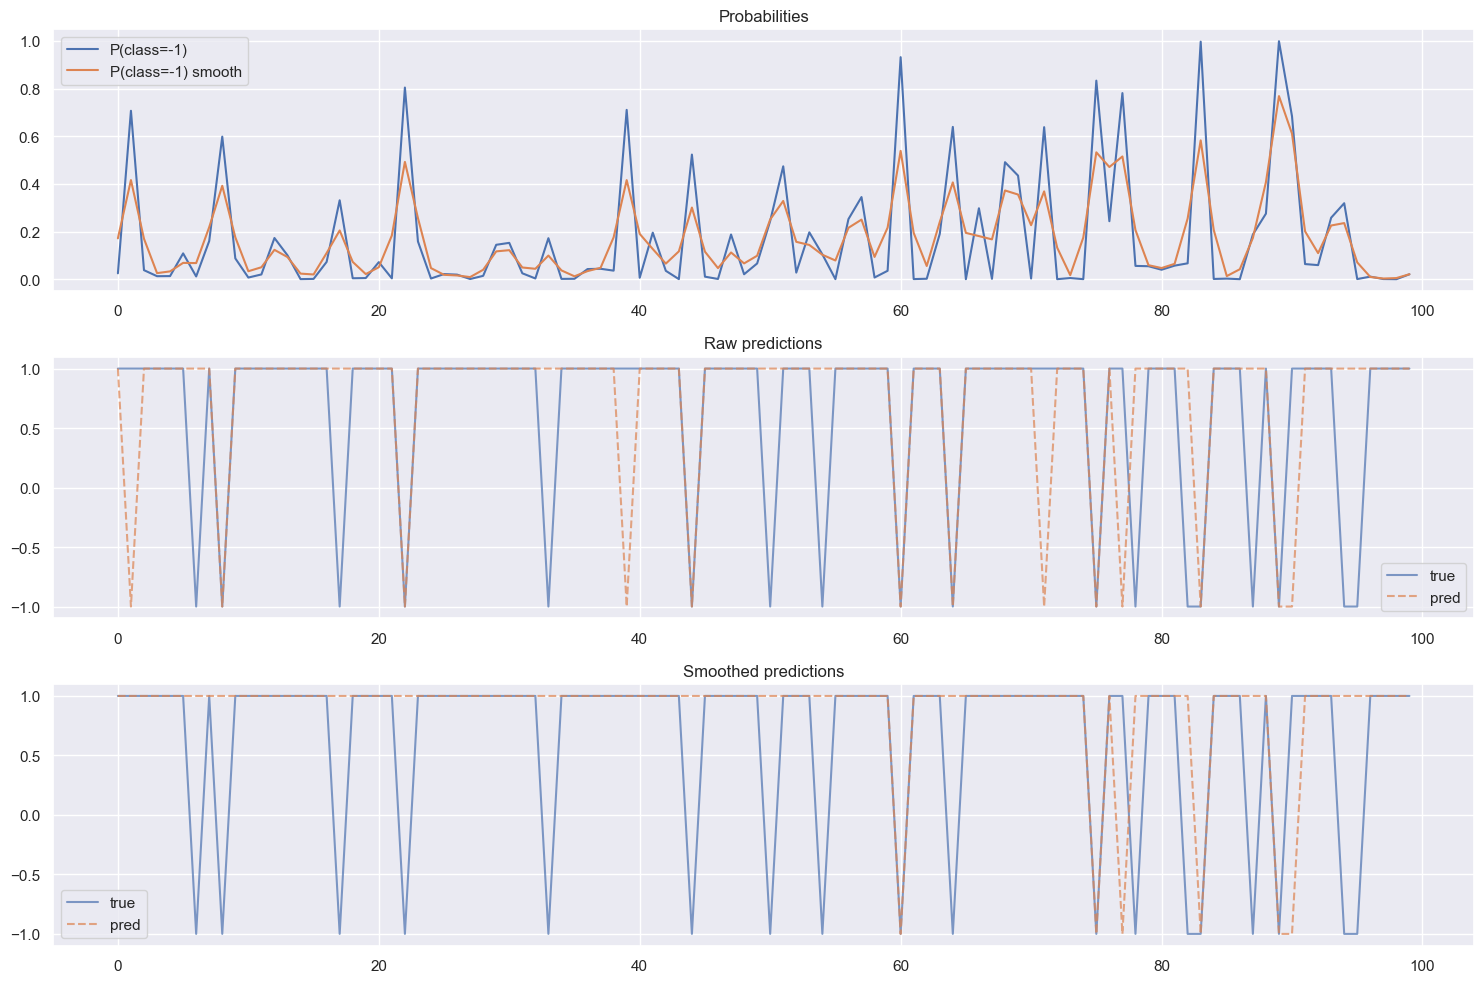

In [104]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))
limit = 100

ax1.set_title("Probabilities")
sns.lineplot(preds_probas[:limit, 0], label=f"P(class={pipeline.classes_[0]})", ax=ax1)
sns.lineplot(preds_probas_smooth[:limit, 0], label=f"P(class={pipeline.classes_[0]}) smooth", ax=ax1)

ax2.set_title("Raw predictions")
sns.lineplot(y_test[:limit], label="true", ax=ax2, alpha=0.7)
sns.lineplot(preds_raw[:limit], label="pred", ax=ax2, alpha=0.7, linestyle="--")

ax3.set_title("Smoothed predictions")
sns.lineplot(y_test[:limit], label="true", ax=ax3, alpha=0.7)
sns.lineplot(preds_smooth[:limit], label="pred", ax=ax3, alpha=0.7, linestyle="--")

plt.tight_layout()

In [96]:
print(f1_score(y_test, preds_raw))
print(f1_score(y_test, preds_smooth))

print(classification_report(y_test, preds_raw))
print(classification_report(y_test, preds_smooth))

0.9355322338830585
0.9420133815273398
              precision    recall  f1-score   support

          -1       0.56      0.47      0.51      1823
           1       0.93      0.95      0.94     12531

    accuracy                           0.89     14354
   macro avg       0.74      0.71      0.72     14354
weighted avg       0.88      0.89      0.88     14354

              precision    recall  f1-score   support

          -1       0.68      0.33      0.44      1823
           1       0.91      0.98      0.94     12531

    accuracy                           0.89     14354
   macro avg       0.79      0.65      0.69     14354
weighted avg       0.88      0.89      0.88     14354

